LAB 10: Recognise handwritten digits (0â€“9) using KNN on MNIST subset

Full Pipeline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# from sklearn.datasets import fetch_openml # Commenting out problematic import
import tensorflow as tf # Import TensorFlow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# â– â–  Load MNIST using tf.keras.datasets (more robust) â– â– â– â– â– â– â– â– â– â– â– 
print('Loading MNIST dataset...')
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# Combine train and test for consistent processing as per original fetch_openml output structure
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

# Flatten the images from 28x28 to 784 features
X = X.reshape(X.shape[0], -1)

print(f'Full dataset: {X.shape}') # (70000, 784)
# Ensure y is integer type, as fetch_openml does
y = y.astype(int)

Loading MNIST dataset...
11490434/11490434 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 0us/step
Full dataset: (70000, 784)


In [3]:
# â– â–  Use 10,000 samples (full set takes ~10 min to predict) â– â– â– â– 
X, y = X[:10000], y[:10000]
X_train,X_test,y_train,y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape} Test: {X_test.shape}')

Train: (8000, 784) Test: (2000, 784)


In [4]:
# â– â–  Scale pixels 0-255 to standardised values â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– 
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train.astype(float))
Xte_s = scaler.transform(X_test.astype(float))

In [5]:
# â– â–  Train KNN (ball_tree is faster for high-dim data) â– â– â– â– â– â– â– â– â– 
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean',
algorithm='ball_tree', n_jobs=-1)
knn.fit(Xtr_s, y_train)

KNeighborsClassifier(algorithm='ball_tree', metric='euclidean', n_jobs=-1)

In [6]:
# â– â–  Evaluate â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– 
y_pred = knn.predict(Xte_s)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print(classification_report(y_test, y_pred))

Test Accuracy: 90.50%
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       200
           1       0.87      0.99      0.93       225
           2       0.91      0.84      0.87       198
           3       0.89      0.92      0.90       206
           4       0.93      0.85      0.89       196
           5       0.91      0.89      0.90       173
           6       0.95      0.95      0.95       203
           7       0.92      0.87      0.89       214
           8       0.93      0.83      0.88       189
           9       0.85      0.91      0.88       196

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.91      0.91      0.90      2000



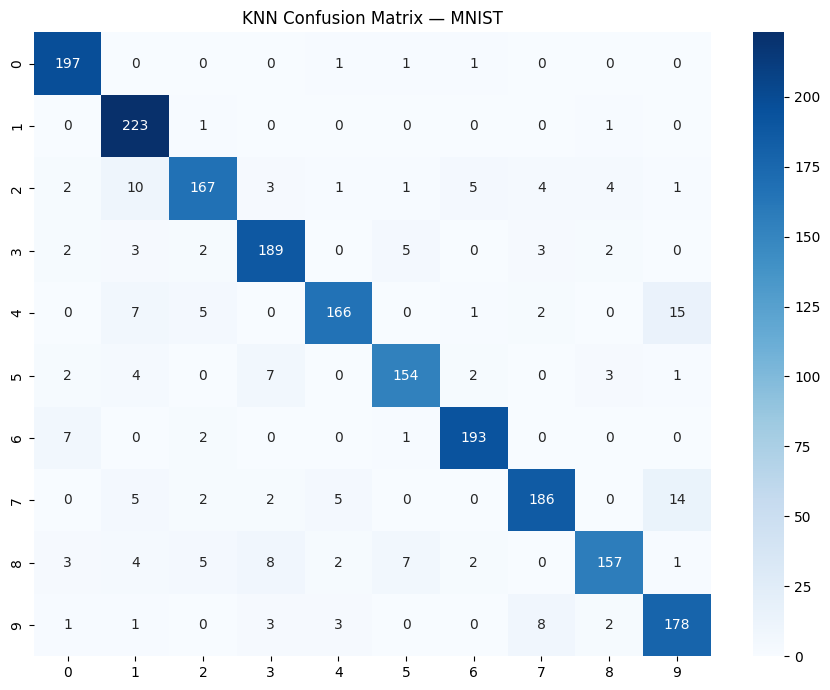

In [7]:
# â– â–  Confusion matrix â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title('KNN Confusion Matrix â€” MNIST'); plt.tight_layout(); plt.show()

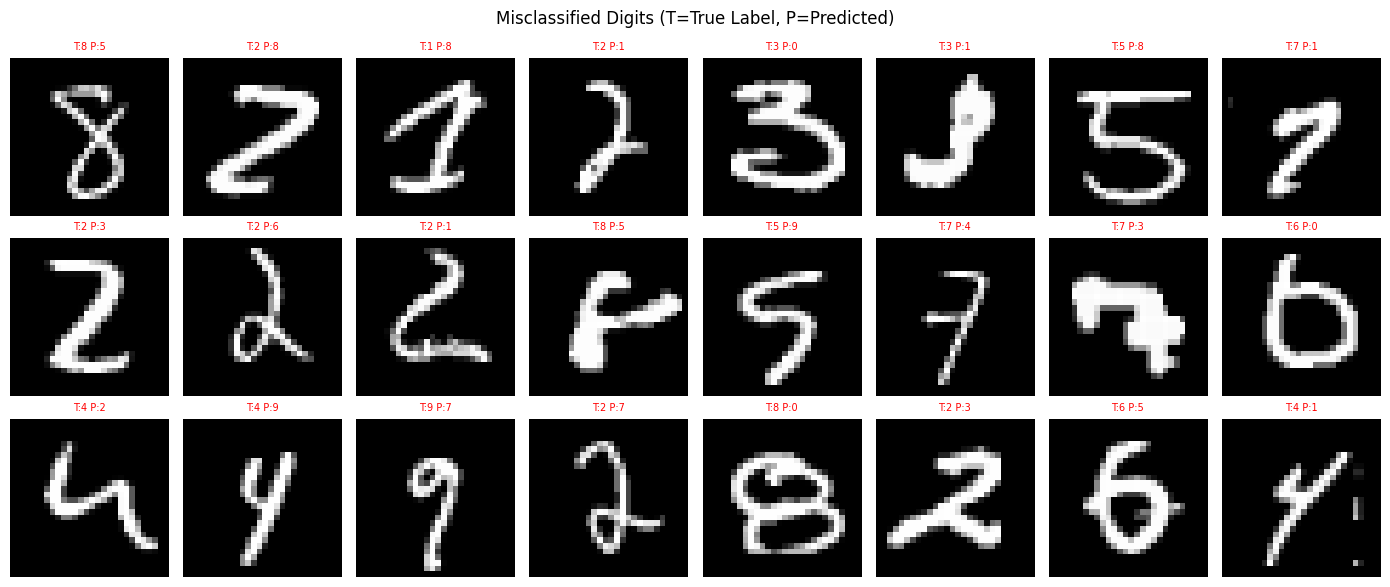

In [8]:
# â– â–  Show misclassified images â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– 
wrong = np.where(y_pred != y_test)[0]
fig, axes = plt.subplots(3,8,figsize=(14,6))
for i,ax in enumerate(axes.flat):
  if i < len(wrong):
    ax.imshow(X_test[wrong[i]].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[wrong[i]]} P:{y_pred[wrong[i]]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True Label, P=Predicted)')
plt.tight_layout(); plt.show()

In [9]:
# â– â–  Compare K values â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– 
for k in [1,3,5,7,9]:
  kk = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
  kk.fit(Xtr_s, y_train)
print(f'K={k} Accuracy={accuracy_score(y_test, kk.predict(Xte_s))*100:.2f}%')

K=9 Accuracy=90.70%
